# 🟢 미션 1 (필수) — 히트맵 뽑고 · 가중치 읽고 · 왜인지 쓰기

세 가지를 한다:
1. **뽑기** — 내가 고른 날짜를 **재정렬 포맷 하나** + **OOD(처음 보는 입력) 하나**로 히트맵
2. **읽기** — 재정렬 히트맵에서 출력 연도 글자의 **가중치를 숫자로** 확인
3. **쓰기** — 어느 출력이 어느 입력을 봤는지 + OOD는 왜 흔들리는지 **두 줄**

제출: 히트맵 1장(`my_alignment.png`) + 두 줄.

In [1]:
import sys
# 노트북(cwd=이 폴더)에서도, .py 를 상위에서 돌려도 attn/koplot 을 찾게 한다.
# ⚠️ __file__ 은 주피터 커널에 정의되지 않는다 — 노트북에서 NameError 로 죽는다.
sys.path[:0] = ["..", "."]

import matplotlib
# 노트북이면 그림이 셀 아래에 바로 뜬다. 터미널이면 화면 없이 파일로만 저장한다.
NOTEBOOK = "ipykernel" in sys.modules
if not NOTEBOOK:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import koplot; koplot.use_korean()

from dates import DateData
from model import train, translate
from viz import plot_alignment, print_weight_row

data = DateData(n=8000, seed=0)
enc, dec = train(data, epochs=6)

[koplot] 한글 폰트 적용: NanumGothic
  epoch 0  loss 1.849  (2.6s)
  epoch 1  loss 0.993  (4.9s)
  epoch 2  loss 0.551  (7.2s)
  epoch 3  loss 0.227  (9.5s)
  epoch 4  loss 0.051  (11.7s)
  epoch 5  loss 0.016  (14.0s)


## 1. 재정렬 포맷으로 뽑기 — 여기 두 줄만 바꾼다
재정렬 포맷: `27 July 2026` · `July 27, 2026` · `27/07/2026` 꼴

3 March 2001 -> 2001-03-03


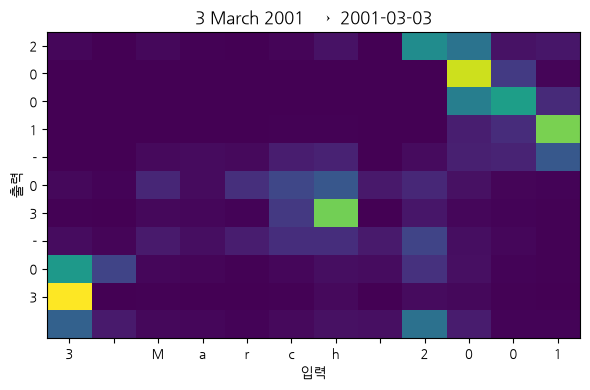

In [2]:
MY_DATE = "3 March 2001"       # TODO: 내 날짜(재정렬 포맷)로

pred, A = translate(enc, dec, data, MY_DATE)
plot_alignment(MY_DATE, pred, A)
plt.savefig("my_alignment.png", dpi=120)
print(f"{MY_DATE} -> {pred}")
if not NOTEBOOK:
    plt.close()                # 노트북에서는 닫지 않는다 — 닫으면 셀에 안 보인다

## 2. 가중치를 숫자로 — 출력 연도 첫 글자(0번째)

In [ ]:
print_weight_row(MY_DATE, pred, A, out_idx=0)
# TODO(쓰기): 값이 가장 큰 입력은 어디였나? 그게 왜 그 위치인가? 한 줄.
# 출력 연도의 첫 번째 글자(out_idx=0)는 입력의 "2001" 위치에 가장 큰 Attention Weight를 두었다.
# 이는 연도를 생성하기 위해 입력의 연도 정보를 가장 중요하게 참고했기 때문이다.

출력 '2' (출력 0번째)의 어텐션 가중치 — 합 = 0.98
  입력[ 0] '3'   0.02  █
  입력[ 1] '　'   0.00  
  입력[ 2] 'M'   0.02  █
  입력[ 3] 'a'   0.01  
  입력[ 4] 'r'   0.00  
  입력[ 5] 'c'   0.01  
  입력[ 6] 'h'   0.04  █
  입력[ 7] '　'   0.00  
  입력[ 8] '2'   0.44  █████████████
  입력[ 9] '0'   0.34  ██████████
  입력[10] '0'   0.05  █
  입력[11] '1'   0.06  ██


## 3. OOD — 처음 보는 입력 하나
예: `Mar 3 2001`(약자) · `2001.03.03`(점) · `31 March 2001`(3월 31일이 있나?) 중 하나

In [ ]:
MY_OOD = "Mar 3 2001"          # TODO: OOD 하나 골라 바꾸기
p, a = translate(enc, dec, data, MY_OOD)
print(f"{MY_OOD} -> {p}")
# TODO(쓰기): 제대로 나왔나 흔들렸나? 모델이 이 입력을 왜 어려워하나? 한 줄.
# 학습 데이터에 없는 날짜 형식이므로 모델이 입력 패턴을 제대로 인식하지 못해 번역 성능이 저하되었다.

NameError: name 'translate' is not defined